# 1

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# 2

In [2]:
CHECKPOINT_PATH = Path(r"C:\Users\Hoannd\Downloads\data_face\vfa_work\project_checkpoint_state.json")

print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("Checkpoint path:", CHECKPOINT_PATH)

with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
    state = json.load(f)

state

Checkpoint exists: True
Checkpoint path: C:\Users\Hoannd\Downloads\data_face\vfa_work\project_checkpoint_state.json


{'created_at': '2026-05-12 18:11:27',
 'base_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face',
 'processed_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\processed_vfa',
 'face_crop_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\processed_vfa_face_crop',
 'out_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work',
 'model_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models',
 'split_metadata': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work\\vfa_split_metadata.csv',
 'crop_metadata': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work\\vfa_face_crop_metadata.csv',
 'best_model': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\vfa_mobilenetv3_small_best.pth',
 'deploy_config': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\vfa_deploy_config.json',
 'note': 'Continue from this checkpoint. Do not rerun raw scan/copy/crop unless needed.'}

# 3

In [3]:
BASE_DIR = Path(state["base_dir"])
PROCESSED_DIR = Path(state["processed_dir"])
FACE_CROP_DIR = Path(state["face_crop_dir"])
OUT_DIR = Path(state["out_dir"])
MODEL_DIR = Path(state["model_dir"])

TRAIN_DIR = FACE_CROP_DIR / "train"
VAL_DIR = FACE_CROP_DIR / "val"
TEST_DIR = FACE_CROP_DIR / "test"

print("BASE_DIR:", BASE_DIR, BASE_DIR.exists())
print("FACE_CROP_DIR:", FACE_CROP_DIR, FACE_CROP_DIR.exists())
print("TRAIN_DIR:", TRAIN_DIR, TRAIN_DIR.exists())
print("VAL_DIR:", VAL_DIR, VAL_DIR.exists())
print("TEST_DIR:", TEST_DIR, TEST_DIR.exists())
print("MODEL_DIR:", MODEL_DIR, MODEL_DIR.exists())

BASE_DIR: C:\Users\Hoannd\Downloads\data_face True
FACE_CROP_DIR: C:\Users\Hoannd\Downloads\data_face\processed_vfa_face_crop True
TRAIN_DIR: C:\Users\Hoannd\Downloads\data_face\processed_vfa_face_crop\train True
VAL_DIR: C:\Users\Hoannd\Downloads\data_face\processed_vfa_face_crop\val True
TEST_DIR: C:\Users\Hoannd\Downloads\data_face\processed_vfa_face_crop\test True
MODEL_DIR: C:\Users\Hoannd\Downloads\data_face\models True


# 4

In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(root_dir):
    rows = []
    for split in ["train", "val", "test"]:
        for label in ["real", "fake"]:
            folder = root_dir / split / label
            count = 0
            if folder.exists():
                count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
            rows.append({
                "root": root_dir.name,
                "split": split,
                "label": label,
                "count": count
            })
    return pd.DataFrame(rows)

df_count_crop = count_images(FACE_CROP_DIR)
display(df_count_crop)

,root,split,label,count
0,processed_vfa_face_crop,train,real,5745
1,processed_vfa_face_crop,train,fake,2124
2,processed_vfa_face_crop,val,real,1014
3,processed_vfa_face_crop,val,fake,375
4,processed_vfa_face_crop,test,real,782
5,processed_vfa_face_crop,test,fake,1336


# 5

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

Device: cpu


# 6

In [6]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.03
    ),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 7

In [7]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds = datasets.ImageFolder(VAL_DIR, transform=eval_tfms)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tfms)

print("Classes:", train_ds.classes)
print("Class to idx:", train_ds.class_to_idx)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}
idx_to_class

Classes: ['fake', 'real']
Class to idx: {'fake': 0, 'real': 1}
Train: 7869
Val: 1389
Test: 2118


{0: 'fake', 1: 'real'}

# 8

In [8]:
BATCH_SIZE = 32
NUM_WORKERS = 0  # Windows notebook nên để 0 để tránh lỗi multiprocessing

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 246
Val batches: 44
Test batches: 67


# 9

In [9]:
train_labels = [label for _, label in train_ds.samples]
label_counter = Counter(train_labels)

print("Label counter:", label_counter)
print("Class names:", train_ds.classes)

num_classes = len(train_ds.classes)
total = sum(label_counter.values())

class_weights = []

for class_idx in range(num_classes):
    count = label_counter[class_idx]
    weight = total / (num_classes * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Label counter: Counter({1: 5745, 0: 2124})
Class names: ['fake', 'real']
Class weights: tensor([1.8524, 0.6849])


# 10

In [10]:
model = models.mobilenet_v3_small(
    weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
)

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=2, bias=True)
)


# 11

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# 12

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        pos_label=train_ds.class_to_idx["real"],
        zero_division=0
    )
    
    return epoch_loss, epoch_acc, precision, recall, f1


def evaluate(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            loss = criterion(logits, labels)
            
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            running_loss += loss.item() * images.size(0)
            
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        pos_label=train_ds.class_to_idx["real"],
        zero_division=0
    )
    
    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

# 13

In [13]:
EPOCHS = 10

best_val_f1 = 0.0
best_model_path = MODEL_DIR / "vfa_mobilenetv3_small_face_crop_best.pth"

history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )
    
    val_result = evaluate(
        model,
        val_loader,
        criterion,
        device
    )
    
    scheduler.step(val_result["f1"])
    
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "val_loss": val_result["loss"],
        "val_acc": val_result["acc"],
        "val_precision": val_result["precision"],
        "val_recall": val_result["recall"],
        "val_f1": val_result["f1"],
        "lr": optimizer.param_groups[0]["lr"]
    }
    
    history.append(row)
    
    print(
        f"Train loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | "
        f"Val loss={val_result['loss']:.4f} acc={val_result['acc']:.4f} f1={val_result['f1']:.4f}"
    )
    
    if val_result["f1"] > best_val_f1:
        best_val_f1 = val_result["f1"]
        
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_ds.class_to_idx,
            "classes": train_ds.classes,
            "img_size": IMG_SIZE,
            "epoch": epoch,
            "val_f1": best_val_f1,
            "dataset": "processed_vfa_face_crop"
        }, best_model_path)
        
        print("Saved best model:", best_model_path)

df_history = pd.DataFrame(history)
display(df_history)


Epoch 1/10


Train loss=0.3670 acc=0.8384 f1=0.8834 | Val loss=0.2283 acc=0.9158 f1=0.9410
Saved best model: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_face_crop_best.pth

Epoch 2/10


Train loss=0.2330 acc=0.9016 f1=0.9305 | Val loss=0.1973 acc=0.9330 f1=0.9533
Saved best model: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_face_crop_best.pth

Epoch 3/10


Train loss=0.1840 acc=0.9258 f1=0.9478 | Val loss=0.2001 acc=0.9273 f1=0.9491

Epoch 4/10


Train loss=0.1574 acc=0.9362 f1=0.9553 | Val loss=0.1667 acc=0.9388 f1=0.9581
Saved best model: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_face_crop_best.pth

Epoch 5/10


...

Train loss=0.0982 acc=0.9600 f1=0.9722 | Val loss=0.2034 acc=0.9330 f1=0.9538

Epoch 8/10


Train loss=0.0663 acc=0.9732 f1=0.9814 | Val loss=0.2037 acc=0.9431 f1=0.9611
Saved best model: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_face_crop_best.pth

Epoch 9/10


Train loss=0.0617 acc=0.9748 f1=0.9826 | Val loss=0.2136 acc=0.9438 f1=0.9616
Saved best model: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_face_crop_best.pth

Epoch 10/10


Train loss=0.0577 acc=0.9775 f1=0.9845 | Val loss=0.2257 acc=0.9417 f1=0.9600


,epoch,train_loss,train_acc,train_precision,train_recall,train_f1,val_loss,val_acc,val_precision,val_recall,val_f1,lr
0,1,0.366959,0.838353,0.932843,0.838990,0.883431,0.228262,0.915767,0.962848,0.920118,0.940998,0.00010
1,2,0.232970,0.901639,0.961389,0.901480,0.930471,0.197305,0.933045,0.970378,0.936884,0.953337,0.00010
2,3,0.184041,0.925785,0.973573,0.923412,0.947829,0.200111,0.927286,0.971104,0.928008,0.949067,0.00010
3,4,0.157440,0.936205,0.977070,0.934552,0.955338,0.166654,0.938805,0.957635,0.958580,0.958107,0.00010
4,5,0.130415,0.946118,0.981538,0.943951,0.962378,0.199925,0.934485,0.971399,0.937870,0.954340,0.00010
5,6,0.111540,0.955522,0.985773,0.952829,0.969021,0.200687,0.938805,0.978373,0.936884,0.957179,0.00010
6,7,0.098158,0.959970,0.986908,0.957876,0.972176,0.203441,0.933045,0.960961,0.946746,0.953800,0.00005
7,8,0.066312,0.973186,0.992875,0.970235,0.981424,0.203722,0.943125,0.958783,0.963511,0.961141,0.00005
8,9,0.061691,0.974838,0.993067,0.972324,0.982586,0.213559,0.943844,0.960630,0.962525,0.961576,0.00005
9,10,0.057735,0.977507,0.992918,0.976153,0.984464,0.225693,0.941685,0.961424,0.958580,0.960000,0.00005


# 14

In [14]:
history_path = MODEL_DIR / "vfa_face_crop_train_history.csv"

df_history.to_csv(history_path, index=False, encoding="utf-8-sig")

print("Saved history:", history_path)

Saved history: C:\Users\Hoannd\Downloads\data_face\models\vfa_face_crop_train_history.csv


# 15

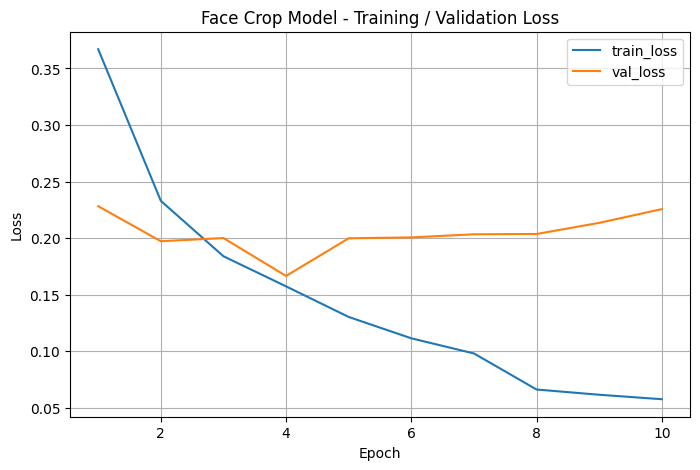

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_loss"], label="train_loss")
plt.plot(df_history["epoch"], df_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Face Crop Model - Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 16

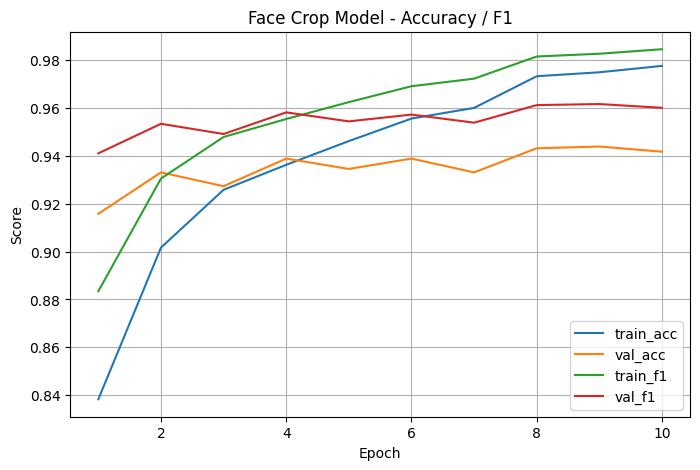

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_acc"], label="train_acc")
plt.plot(df_history["epoch"], df_history["val_acc"], label="val_acc")
plt.plot(df_history["epoch"], df_history["train_f1"], label="train_f1")
plt.plot(df_history["epoch"], df_history["val_f1"], label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Face Crop Model - Accuracy / F1")
plt.legend()
plt.grid(True)
plt.show()

# 17

In [17]:
checkpoint = torch.load(best_model_path, map_location=device)

best_model = models.mobilenet_v3_small(weights=None)
in_features = best_model.classifier[3].in_features
best_model.classifier[3] = nn.Linear(in_features, num_classes)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

print("Loaded:", best_model_path)
print("Classes:", checkpoint["classes"])
print("Best epoch:", checkpoint["epoch"])
print("Best val_f1:", checkpoint["val_f1"])

Loaded: C:\Users\Hoannd\Downloads\data_face\models\vfa_mobilenetv3_small_face_crop_best.pth
Classes: ['fake', 'real']
Best epoch: 9
Best val_f1: 0.961576354679803


# 18

In [18]:
test_result = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test loss:", test_result["loss"])
print("Test acc:", test_result["acc"])
print("Test precision:", test_result["precision"])
print("Test recall:", test_result["recall"])
print("Test f1:", test_result["f1"])

Test loss: 0.2229878216844696
Test acc: 0.9301227573182247
Test precision: 0.8791866028708134
Test recall: 0.9398976982097187
Test f1: 0.9085290482076638


# 19

In [19]:
y_true = test_result["labels"]
y_pred = test_result["preds"]

print("Class mapping:", train_ds.class_to_idx)

print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.classes,
    digits=4
))

Class mapping: {'fake': 0, 'real': 1}
              precision    recall  f1-score   support

        fake     0.9633    0.9244    0.9435      1336
        real     0.8792    0.9399    0.9085       782

    accuracy                         0.9301      2118
   macro avg     0.9213    0.9321    0.9260      2118
weighted avg     0.9323    0.9301    0.9306      2118



# 20

,pred_fake,pred_real
true_fake,1235,101
true_real,47,735


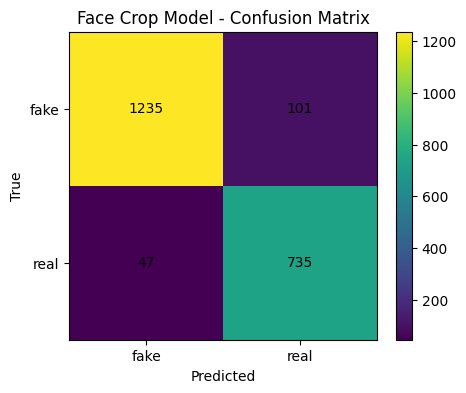

In [20]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in train_ds.classes],
    columns=[f"pred_{c}" for c in train_ds.classes]
)

display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Face Crop Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(train_ds.classes)), train_ds.classes)
plt.yticks(range(len(train_ds.classes)), train_ds.classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()